In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
# ==========================================
# 1. Imports and Device Configuration
# ==========================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import copy

from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error
from sklearn.linear_model import Ridge, Lasso
from sklearn.multioutput import MultiOutputRegressor
from xgboost import XGBRegressor

import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

# Set seeds for reproducibility
np.random.seed(42)
torch.manual_seed(42)

# Device configuration
if torch.cuda.is_available():
    device = torch.device("cuda")
    print("Using GPU: CUDA")
elif hasattr(torch.backends, 'mps') and torch.backends.mps.is_available():
    device = torch.device("mps")
    print("Using GPU: Apple MPS")
else:
    device = torch.device("cpu")
    print("Using CPU")

Using GPU: CUDA


In [ ]:
# ==========================================
# 2. Data Loading, Imputation & Feature Engineering
# ==========================================
file_path = "/content/drive/MyDrive/STAT946/cleaned_data_toronto_downtown.csv"
df = pd.read_csv(file_path)

df['Datetime'] = pd.to_datetime(df['Datetime'])
df = df.sort_values('Datetime').reset_index(drop=True)

# Select base meteorological and air quality features
base_features = [
    'PM_ppb', 'Temp (°C)', 'Dew Point Temp (°C)', 'Rel Hum (%)',
    'Precip. Amount (mm)', 'Wind Dir (10s deg)', 'Wind Spd (km/h)',
    'Visibility (km)', 'Stn Press (kPa)'
]
df_numeric = df[base_features].copy()

print("Imputing missing values using MICE...")
imputer = IterativeImputer(max_iter=10, random_state=42)
df_imputed = pd.DataFrame(imputer.fit_transform(df_numeric), columns=base_features)

# Apply physical constraints
non_negative_cols = ['PM_ppb', 'Rel Hum (%)', 'Precip. Amount (mm)', 'Wind Spd (km/h)', 'Visibility (km)']
for col in non_negative_cols:
    df_imputed[col] = df_imputed[col].clip(lower=0)

df_imputed['Datetime'] = df['Datetime']

# --- Cyclical Time Features ---
# This gives the models a "clock" to understand diurnal patterns, preventing 24h flatlining
df_imputed['hour'] = df_imputed['Datetime'].dt.hour
df_imputed['month'] = df_imputed['Datetime'].dt.month

df_imputed['hour_sin'] = np.sin(2 * np.pi * df_imputed['hour'] / 24.0)
df_imputed['hour_cos'] = np.cos(2 * np.pi * df_imputed['hour'] / 24.0)
df_imputed['month_sin'] = np.sin(2 * np.pi * df_imputed['month'] / 12.0)
df_imputed['month_cos'] = np.cos(2 * np.pi * df_imputed['month'] / 12.0)

# The new complete feature list
final_features = base_features + ['hour_sin', 'hour_cos', 'month_sin', 'month_cos']

print(f"Dataset shape after imputation and feature engineering: {df_imputed.shape}")

/tmp/ipykernel_609/849382745.py:5: DtypeWarning: Columns (14,16,18,20,28) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(file_path)


Imputing missing values using MICE...
Dataset shape after imputation and feature engineering: (56493, 16)


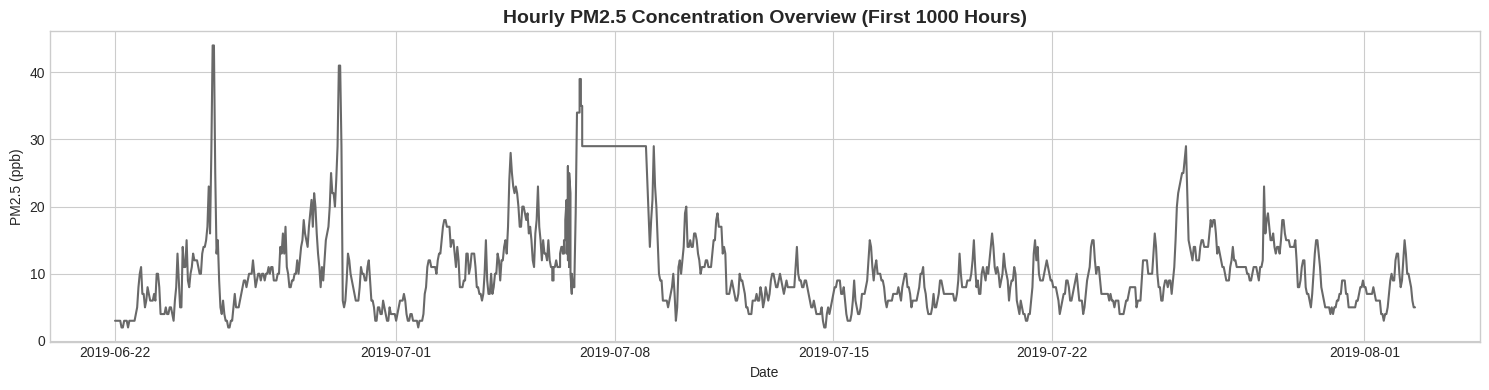

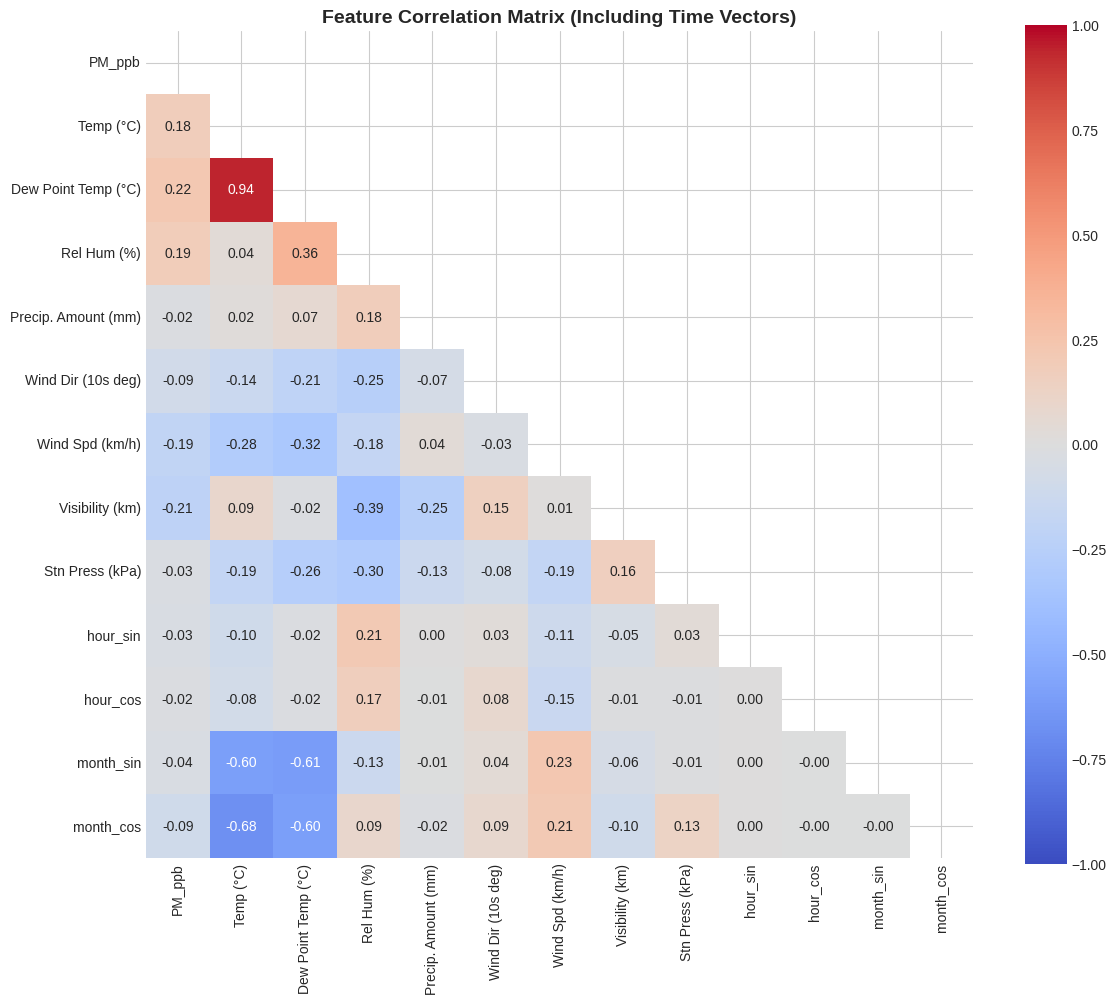

In [4]:
# ==========================================
# 3. Exploratory Data Analysis (EDA)
# ==========================================
plt.style.use('seaborn-v0_8-whitegrid')

# Plot 1: Overall PM2.5 Time Series
plt.figure(figsize=(15, 4))
plt.plot(df_imputed['Datetime'][:1000], df_imputed['PM_ppb'][:1000], color='dimgray', linewidth=1.5)
plt.title('Hourly PM2.5 Concentration Overview (First 1000 Hours)', fontsize=14, fontweight='bold')
plt.ylabel('PM2.5 (ppb)')
plt.xlabel('Date')
plt.tight_layout()
plt.show()

# Plot 2: Feature Correlation Heatmap
plt.figure(figsize=(12, 10))
corr = df_imputed[final_features].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap='coolwarm', vmin=-1, vmax=1, square=True)
plt.title('Feature Correlation Matrix (Including Time Vectors)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

df_model = df_imputed[final_features].copy()

In [5]:
# ==========================================
# 4. Feature Scaling and Sequence Generation
# ==========================================
scaler = StandardScaler()
scaled_data = scaler.fit_transform(df_model)

TARGET_INDEX = 0  # PM_ppb is still index 0
SEQ_LENGTH = 24
HORIZONS = [4, 6, 24]

# Memory pre-allocation prevents RAM spikes
def create_sequences_optimized(data, seq_length, target_idx, horizons):
    max_horizon = max(horizons)
    n_samples = len(data) - seq_length - max_horizon + 1

    xs = np.zeros((n_samples, seq_length, data.shape[1]), dtype=np.float32)
    ys = np.zeros((n_samples, len(horizons)), dtype=np.float32)

    for i in range(n_samples):
        xs[i] = data[i : i + seq_length]
        ys[i] = [data[i + seq_length + h - 1, target_idx] for h in horizons]

    return xs, ys

X, y = create_sequences_optimized(scaled_data, SEQ_LENGTH, TARGET_INDEX, HORIZONS)

# Splits: Train 70%, Val 15%, Test 15%
train_end = int(len(X) * 0.70)
val_end = int(len(X) * 0.85)

X_train, y_train = X[:train_end], y[:train_end]
X_val, y_val = X[train_end:val_end], y[train_end:val_end]
X_test, y_test = X[val_end:], y[val_end:]

# Flatten inputs for traditional ML
X_train_flat = X_train.reshape(X_train.shape[0], -1)
X_test_flat = X_test.reshape(X_test.shape[0], -1)

# Map to PyTorch Tensors
X_train_t = torch.tensor(X_train).to(device)
y_train_t = torch.tensor(y_train).to(device)
X_val_t = torch.tensor(X_val).to(device)
y_val_t = torch.tensor(y_val).to(device)
X_test_t = torch.tensor(X_test).to(device)

train_loader = DataLoader(TensorDataset(X_train_t, y_train_t), batch_size=256, shuffle=True)
val_loader = DataLoader(TensorDataset(X_val_t, y_val_t), batch_size=256, shuffle=False)

predictions_dict = {}
print("Sequence generation completed. Tensors mapped to device.")

Sequence generation completed. Tensors mapped to device.


In [6]:
# ==========================================
# 5. Baseline Models: Ridge, Lasso & XGBoost
# ==========================================
print("Training Ridge Regression...")
ridge = MultiOutputRegressor(Ridge(alpha=1.0))
ridge.fit(X_train_flat, y_train)
predictions_dict['Ridge'] = ridge.predict(X_test_flat)

print("Training Lasso Regression...")
lasso = MultiOutputRegressor(Lasso(alpha=0.01))
lasso.fit(X_train_flat, y_train)
predictions_dict['Lasso'] = lasso.predict(X_test_flat)

print("Training XGBoost...")
xgb = MultiOutputRegressor(XGBRegressor(n_estimators=100, max_depth=6, learning_rate=0.05, random_state=42))
xgb.fit(X_train_flat, y_train)
predictions_dict['XGBoost'] = xgb.predict(X_test_flat)

print("Machine Learning baselines trained successfully.")

Training Ridge Regression...
Training Lasso Regression...
Training XGBoost...
Machine Learning baselines trained successfully.


In [7]:
# ==========================================
# 6. Deep Learning Architectures
# ==========================================
INPUT_DIM = len(final_features)
OUTPUT_DIM = len(HORIZONS)

# 1. LSTM
class ModelLSTM(nn.Module):
    def __init__(self, input_dim, hidden_dim=64, num_layers=2, output_dim=3):
        super().__init__()
        self.lstm = nn.LSTM(input_dim, hidden_dim, num_layers=num_layers, batch_first=True, dropout=0.2)
        self.fc = nn.Sequential(
            nn.Linear(hidden_dim, 32),
            nn.LeakyReLU(0.1), # LeakyReLU allows gradients to flow for extreme spikes
            nn.Dropout(0.1),
            nn.Linear(32, output_dim)
        )
    def forward(self, x):
        out, _ = self.lstm(x)
        return self.fc(out[:, -1, :])

# 2. Transformer
class ModelTransformer(nn.Module):
    def __init__(self, input_dim, d_model=32, nhead=4, num_layers=2, output_dim=3, seq_len=24):
        super().__init__()
        self.input_linear = nn.Linear(input_dim, d_model)
        self.pos_encoder = nn.Parameter(torch.randn(1, seq_len, d_model))
        encoder_layers = nn.TransformerEncoderLayer(d_model=d_model, nhead=nhead, batch_first=True, dropout=0.1)
        self.transformer = nn.TransformerEncoder(encoder_layers, num_layers=num_layers)
        self.fc = nn.Sequential(
            nn.Linear(d_model * seq_len, 64),
            nn.LeakyReLU(0.1),
            nn.Dropout(0.1),
            nn.Linear(64, output_dim)
        )
    def forward(self, x):
        x = self.input_linear(x) + self.pos_encoder
        out = self.transformer(x).reshape(x.size(0), -1)
        return self.fc(out)

# 3. N-HiTS
class ModelNHITS(nn.Module):
    def __init__(self, input_dim, seq_len=24, output_dim=3):
        super().__init__()
        flat_dim = input_dim * seq_len
        self.branch_high = nn.Sequential(
            nn.Linear(flat_dim, 128), nn.LeakyReLU(0.1), nn.Dropout(0.1),
            nn.Linear(128, 64), nn.LeakyReLU(0.1), nn.Linear(64, 32)
        )
        self.pool = nn.MaxPool1d(kernel_size=4)
        pool_len = seq_len // 4
        self.branch_low = nn.Sequential(
            nn.Linear(input_dim * pool_len, 128), nn.LeakyReLU(0.1), nn.Dropout(0.1),
            nn.Linear(128, 64), nn.LeakyReLU(0.1), nn.Linear(64, 32)
        )
        self.fc_out = nn.Linear(32 + 32, output_dim)
    def forward(self, x):
        x_high = x.reshape(x.size(0), -1)
        out_high = self.branch_high(x_high)
        x_low = x.permute(0, 2, 1)
        x_low = self.pool(x_low).reshape(x.size(0), -1)
        out_low = self.branch_low(x_low)
        return self.fc_out(torch.cat((out_high, out_low), dim=1))

# 4. Custom Hybrid: CNN-LSTM-Attention
class ModelHybridCRA(nn.Module):
    def __init__(self, input_dim, seq_len=24, cnn_channels=32, lstm_hidden=64, output_dim=3):
        super().__init__()
        self.conv1d = nn.Conv1d(in_channels=input_dim, out_channels=cnn_channels, kernel_size=3, padding=1)
        self.relu = nn.LeakyReLU(0.1)
        self.lstm = nn.LSTM(input_size=cnn_channels, hidden_size=lstm_hidden, num_layers=2, batch_first=True, dropout=0.2)
        self.attention_weights = nn.Linear(lstm_hidden, 1)
        self.softmax = nn.Softmax(dim=1)
        self.fc_head = nn.Sequential(
            nn.Linear(lstm_hidden, 32), nn.LeakyReLU(0.1), nn.Dropout(0.1), nn.Linear(32, output_dim)
        )
    def forward(self, x):
        x_cnn = x.permute(0, 2, 1)
        c_out = self.relu(self.conv1d(x_cnn))
        lstm_out, _ = self.lstm(c_out.permute(0, 2, 1))
        attn_weights = self.softmax(self.attention_weights(lstm_out))
        context_vector = torch.sum(attn_weights * lstm_out, dim=1)
        return self.fc_head(context_vector)

lstm_model = ModelLSTM(INPUT_DIM, output_dim=OUTPUT_DIM).to(device)
tf_model = ModelTransformer(INPUT_DIM, output_dim=OUTPUT_DIM, seq_len=SEQ_LENGTH).to(device)
nhits_model = ModelNHITS(INPUT_DIM, seq_len=SEQ_LENGTH, output_dim=OUTPUT_DIM).to(device)
hybrid_model = ModelHybridCRA(INPUT_DIM, seq_len=SEQ_LENGTH, output_dim=OUTPUT_DIM).to(device)

In [8]:
# ==========================================
# 7. Deep Learning Training Loop with Early Stopping
# ==========================================
def train_dl_model(model, name, max_epochs=70, lr=0.001, patience=10):
    print(f"\n--- Training {name} ---")
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    # Using SmoothL1Loss instead of pure MSE. It is less sensitive to extreme outliers,
    # preventing the model from becoming overly conservative and flatlining.
    criterion = nn.SmoothL1Loss()

    best_val_loss = float('inf')
    epochs_no_improve = 0
    best_model_wts = copy.deepcopy(model.state_dict())

    for epoch in range(max_epochs):
        model.train()
        train_loss = 0
        for bx, by in train_loader:
            optimizer.zero_grad()
            preds = model(bx)
            loss = criterion(preds, by)
            loss.backward()
            optimizer.step()
            train_loss += loss.item()

        model.eval()
        val_loss = 0
        with torch.no_grad():
            for bx_val, by_val in val_loader:
                val_preds = model(bx_val)
                batch_loss = criterion(val_preds, by_val)
                val_loss += batch_loss.item()

        avg_train = train_loss / len(train_loader)
        avg_val = val_loss / len(val_loader)

        if (epoch+1) % 10 == 0 or epoch == 0:
            print(f"Epoch [{epoch+1}/{max_epochs}] | Train Loss: {avg_train:.4f} | Val Loss: {avg_val:.4f}")

        if avg_val < best_val_loss:
            best_val_loss = avg_val
            epochs_no_improve = 0
            best_model_wts = copy.deepcopy(model.state_dict())
        else:
            epochs_no_improve += 1
            if epochs_no_improve >= patience:
                print(f"Early stopping triggered at Epoch {epoch+1}.")
                break

    print(f"Restoring best weights for {name} (Best Val Loss: {best_val_loss:.4f})")
    model.load_state_dict(best_model_wts)

    model.eval()
    test_preds = []
    with torch.no_grad():
        test_loader = DataLoader(TensorDataset(X_test_t), batch_size=256, shuffle=False)
        for bx_test in test_loader:
            preds = model(bx_test[0]).cpu().numpy()
            test_preds.append(preds)

    predictions_dict[name] = np.vstack(test_preds)

# Train all deep learning models
train_dl_model(lstm_model, "LSTM", max_epochs=70, patience=10)
train_dl_model(tf_model, "Transformer", max_epochs=70, patience=10)
train_dl_model(nhits_model, "N-HiTS", max_epochs=70, patience=10)
train_dl_model(hybrid_model, "Hybrid-CNN-LSTM-Attn", max_epochs=70, patience=10)


--- Training LSTM ---
Epoch [1/70] | Train Loss: 0.2207 | Val Loss: 0.1351
Epoch [10/70] | Train Loss: 0.1601 | Val Loss: 0.1437
Early stopping triggered at Epoch 13.
Restoring best weights for LSTM (Best Val Loss: 0.1295)

--- Training Transformer ---
Epoch [1/70] | Train Loss: 0.2327 | Val Loss: 0.1340
Epoch [10/70] | Train Loss: 0.1760 | Val Loss: 0.1374
Early stopping triggered at Epoch 17.
Restoring best weights for Transformer (Best Val Loss: 0.1308)

--- Training N-HiTS ---
Epoch [1/70] | Train Loss: 0.2123 | Val Loss: 0.1393
Epoch [10/70] | Train Loss: 0.1522 | Val Loss: 0.1491
Early stopping triggered at Epoch 13.
Restoring best weights for N-HiTS (Best Val Loss: 0.1339)

--- Training Hybrid-CNN-LSTM-Attn ---
Epoch [1/70] | Train Loss: 0.2455 | Val Loss: 0.1463
Epoch [10/70] | Train Loss: 0.1676 | Val Loss: 0.1456
Early stopping triggered at Epoch 16.
Restoring best weights for Hybrid-CNN-LSTM-Attn (Best Val Loss: 0.1331)


In [9]:
# ==========================================
# 8. Unscaling Predictions and Metric Calculation
# ==========================================
def inverse_transform_target(scaled_targets):
    dummy = np.zeros((len(scaled_targets), len(final_features)))
    dummy[:, TARGET_INDEX] = scaled_targets
    return scaler.inverse_transform(dummy)[:, TARGET_INDEX]

y_test_raw = np.zeros_like(y_test)
for i in range(len(HORIZONS)):
    y_test_raw[:, i] = inverse_transform_target(y_test[:, i])

results_rmse = {horizon: {} for horizon in HORIZONS}

for model_name, preds_scaled in predictions_dict.items():
    preds_raw = np.zeros_like(preds_scaled)
    for i, h in enumerate(HORIZONS):
        preds_raw[:, i] = inverse_transform_target(preds_scaled[:, i])
        rmse = np.sqrt(mean_squared_error(y_test_raw[:, i], preds_raw[:, i]))
        results_rmse[h][model_name] = rmse

    predictions_dict[model_name] = preds_raw

print("\n=== RMSE Comparison (ppb) ===")
models = list(predictions_dict.keys())
print(f"{'Horizon':<12} | " + " | ".join([f"{m:<20}" for m in models]))
print("-" * 135)
for h in HORIZONS:
    scores = [f"{results_rmse[h][m]:<20.2f}" for m in models]
    print(f"+{h} Hours     | " + " | ".join(scores))


=== RMSE Comparison (ppb) ===
Horizon      | Ridge                | Lasso                | XGBoost              | LSTM                 | Transformer          | N-HiTS               | Hybrid-CNN-LSTM-Attn
---------------------------------------------------------------------------------------------------------------------------------------
+4 Hours     | 6.78                 | 6.81                 | 6.98                 | 6.95                 | 7.23                 | 6.89                 | 7.32                
+6 Hours     | 7.48                 | 7.49                 | 7.71                 | 7.63                 | 7.81                 | 7.56                 | 7.87                
+24 Hours     | 8.63                 | 8.65                 | 8.61                 | 8.82                 | 8.74                 | 8.84                 | 8.99                


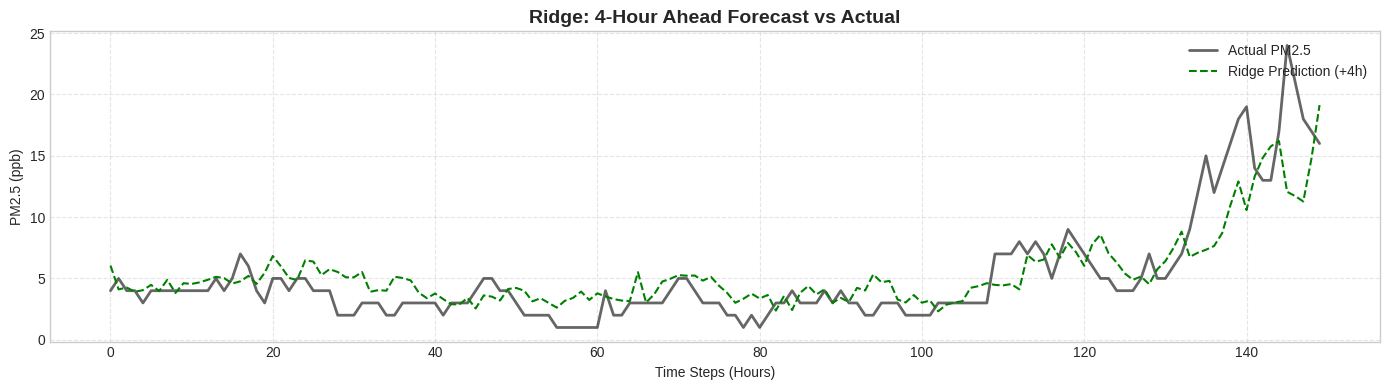

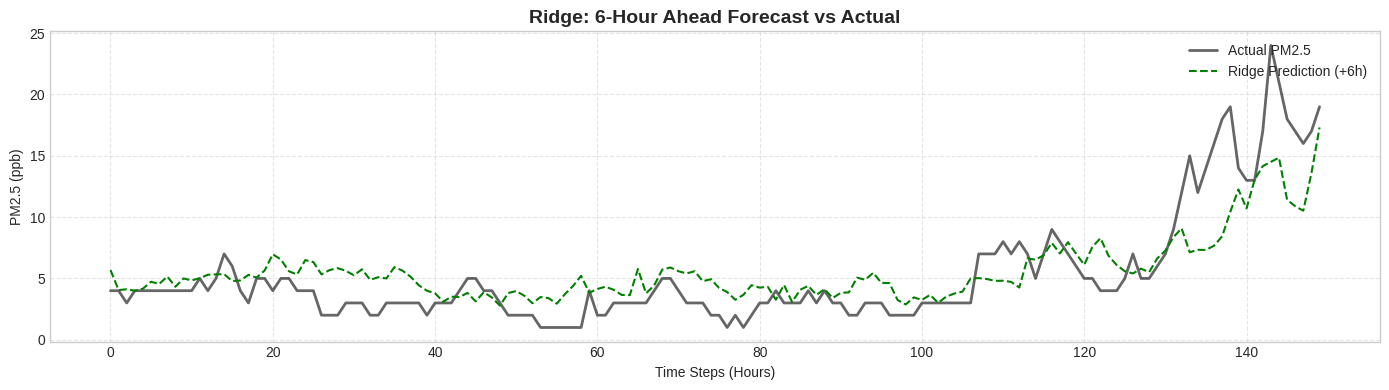

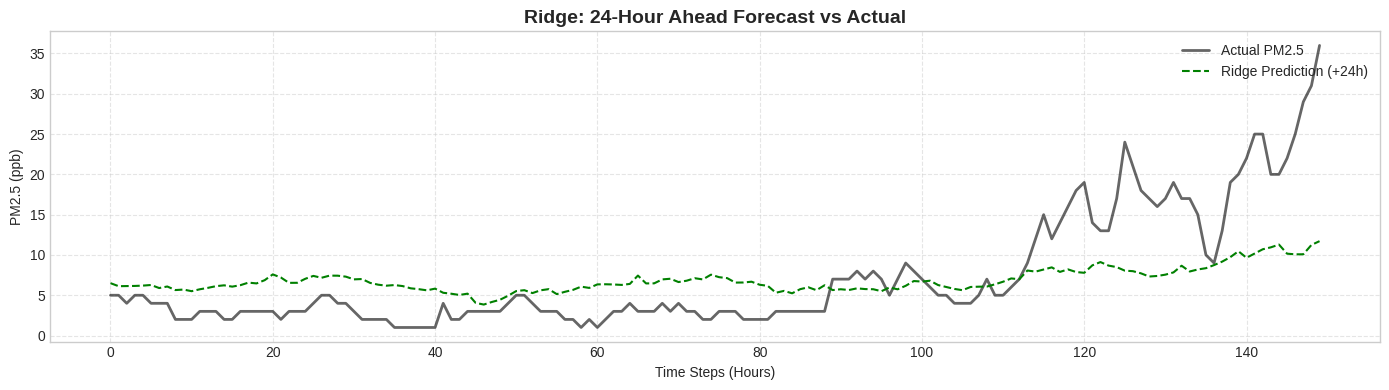

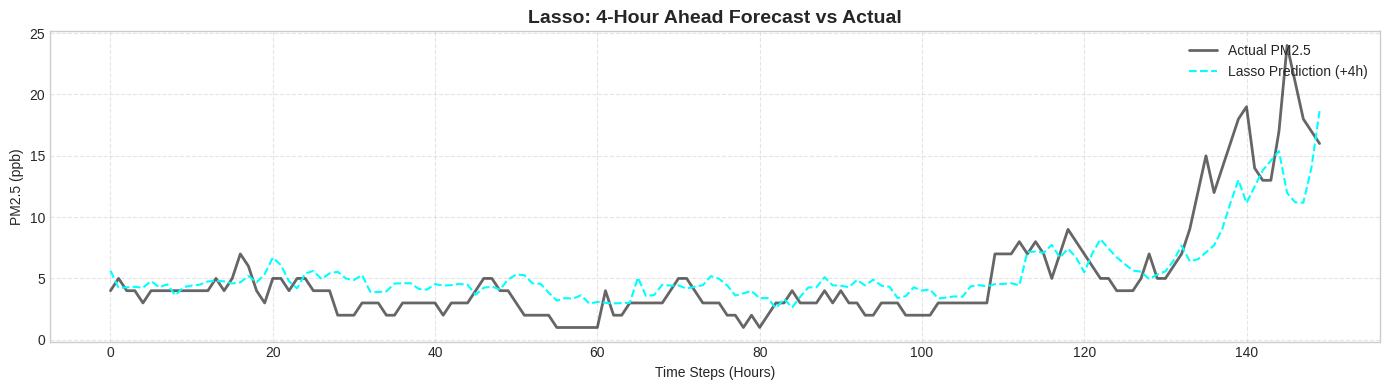

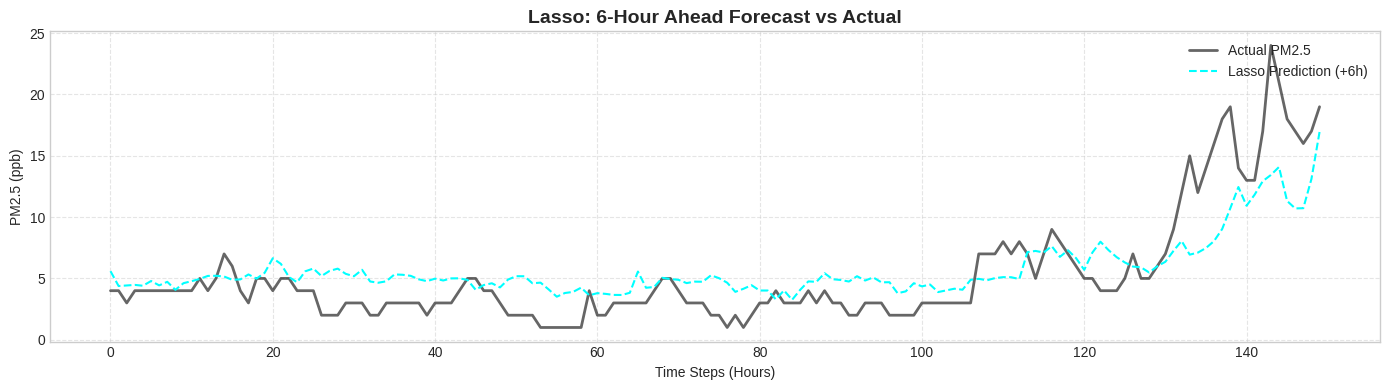

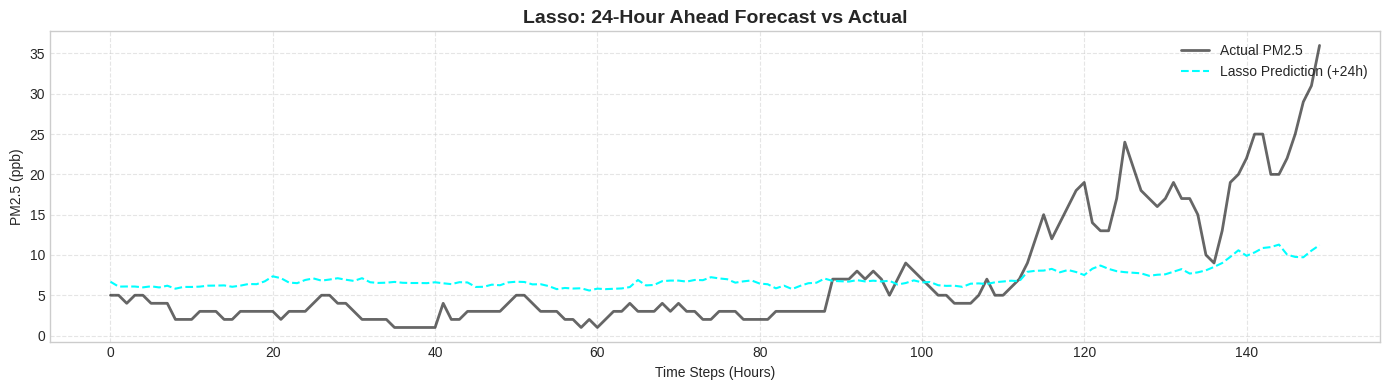

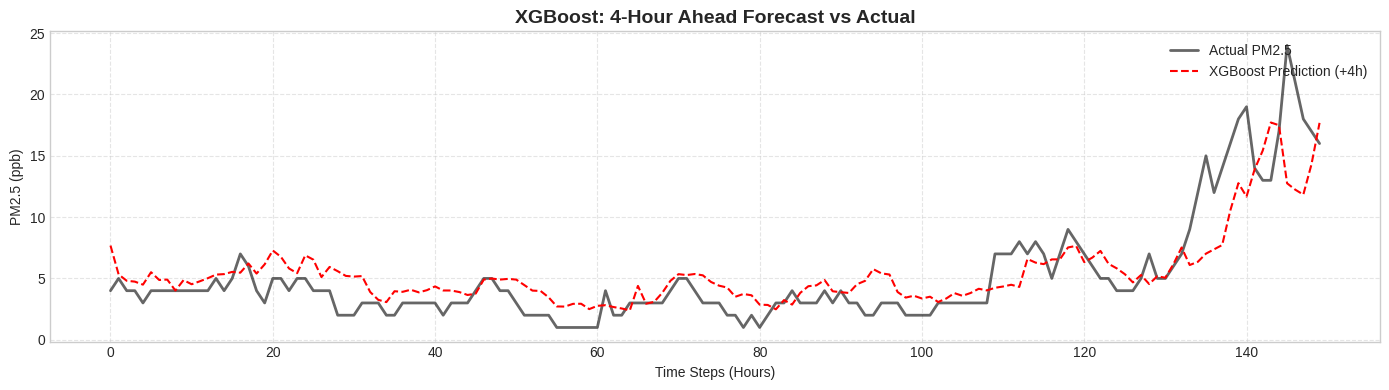

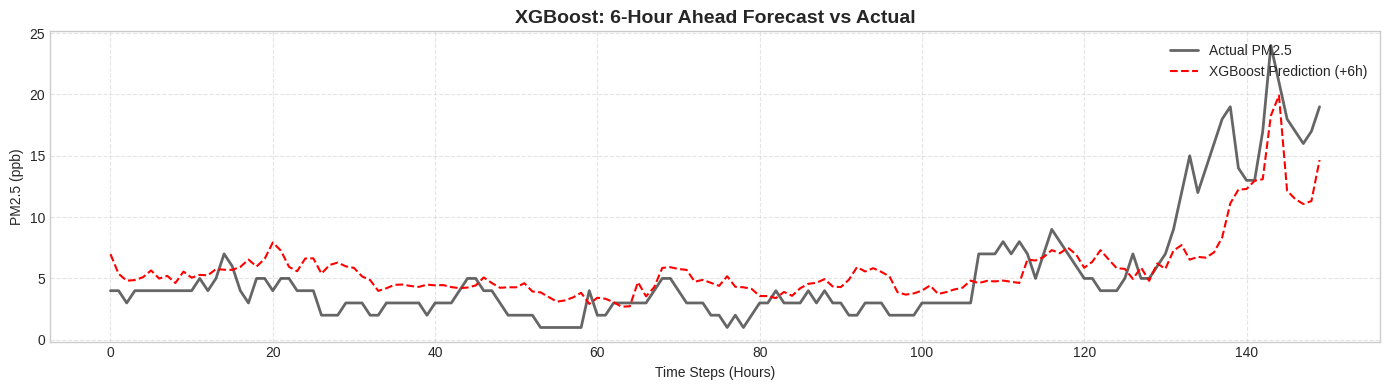

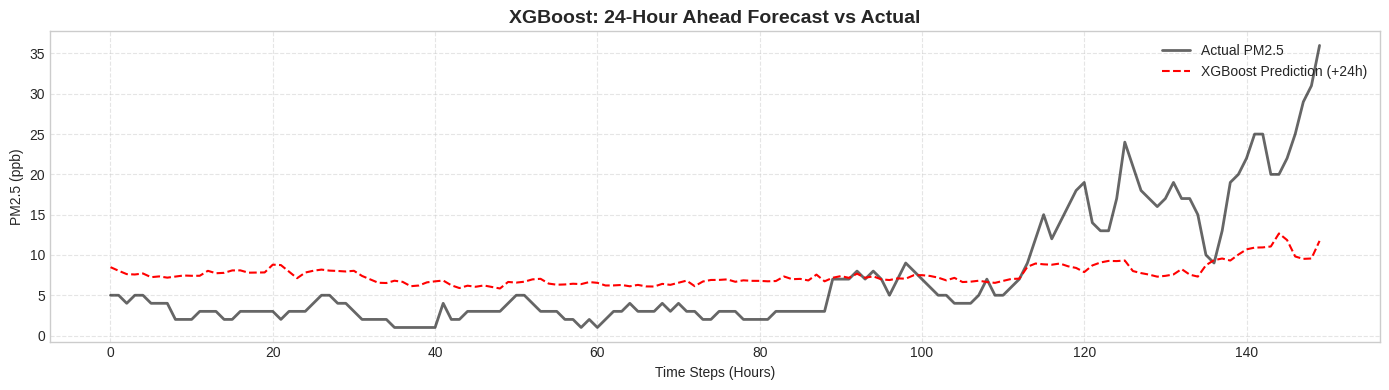

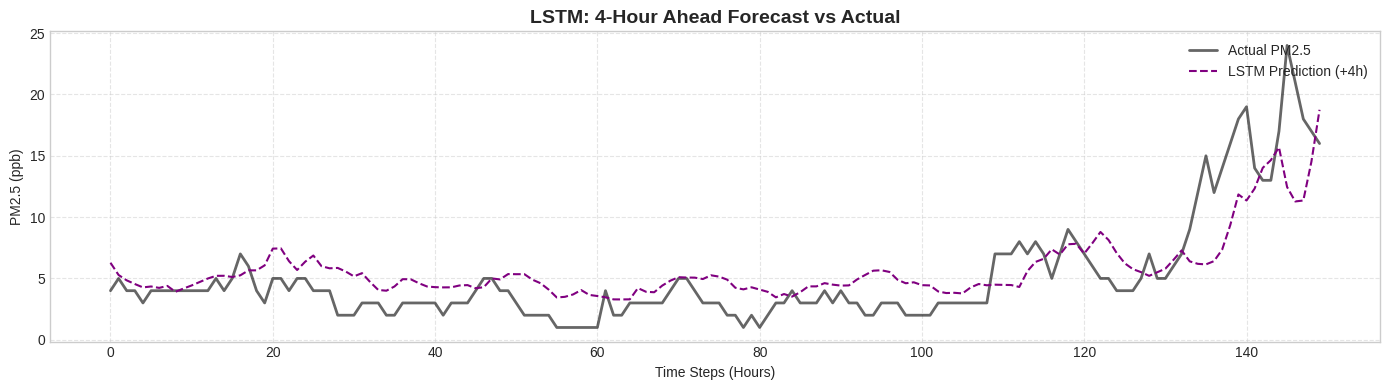

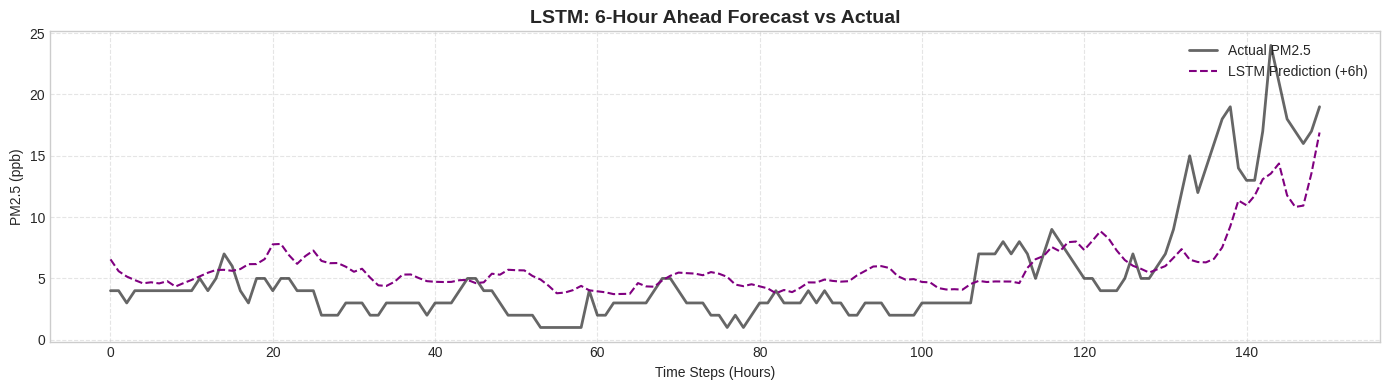

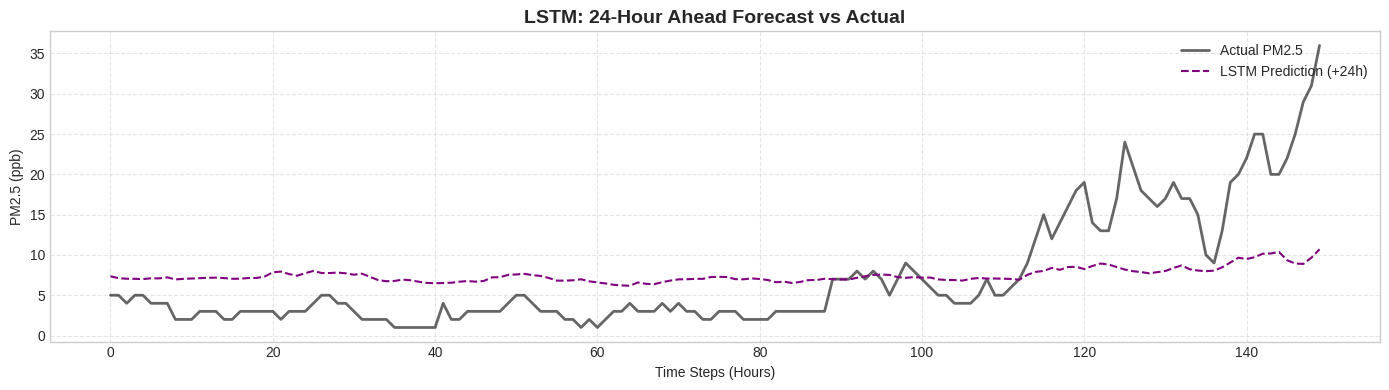

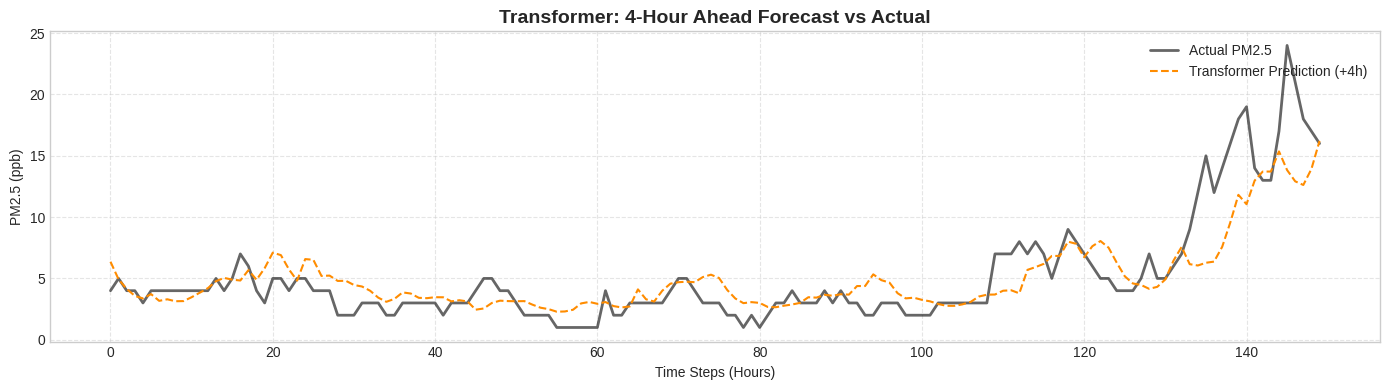

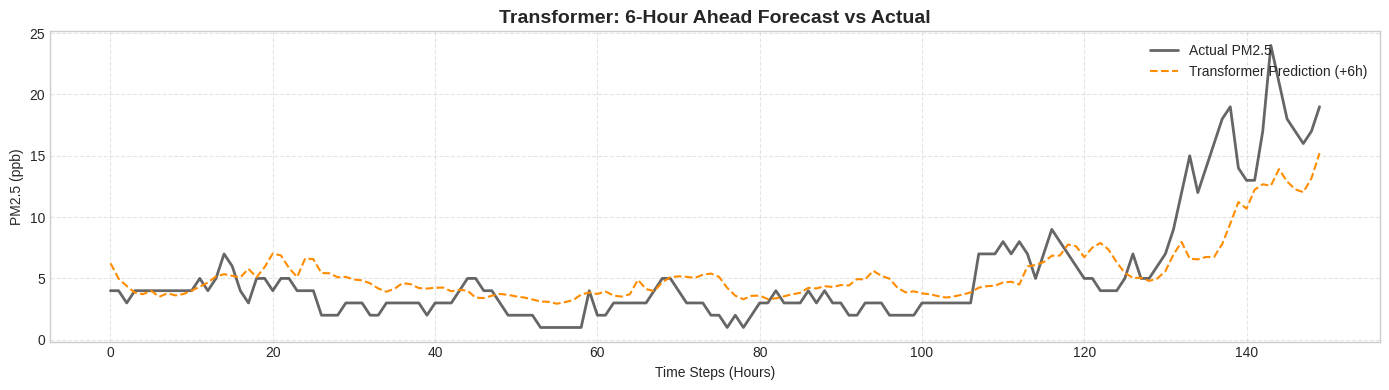

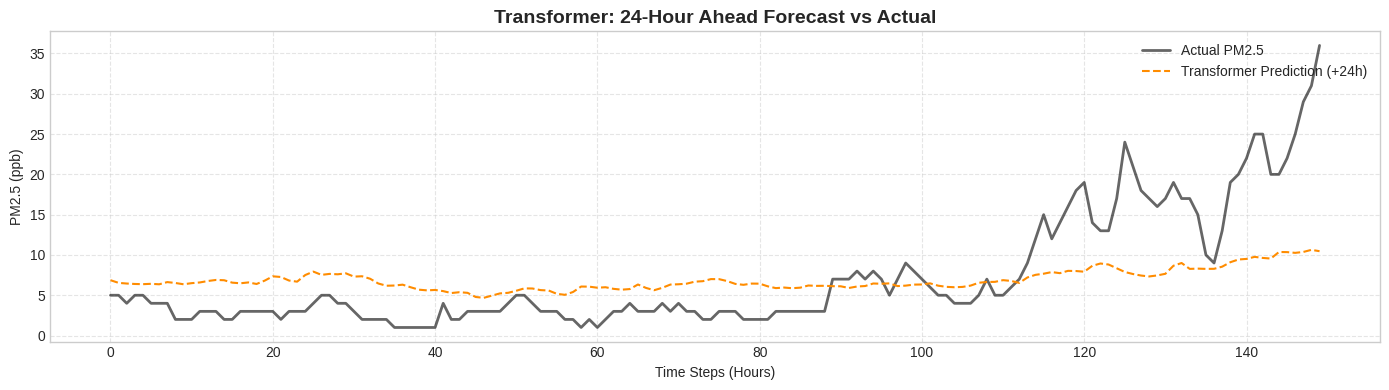

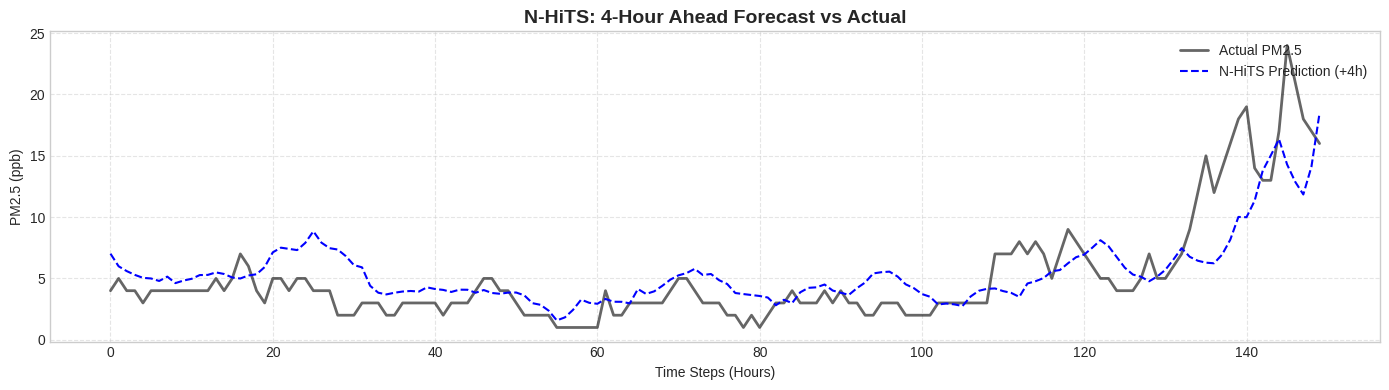

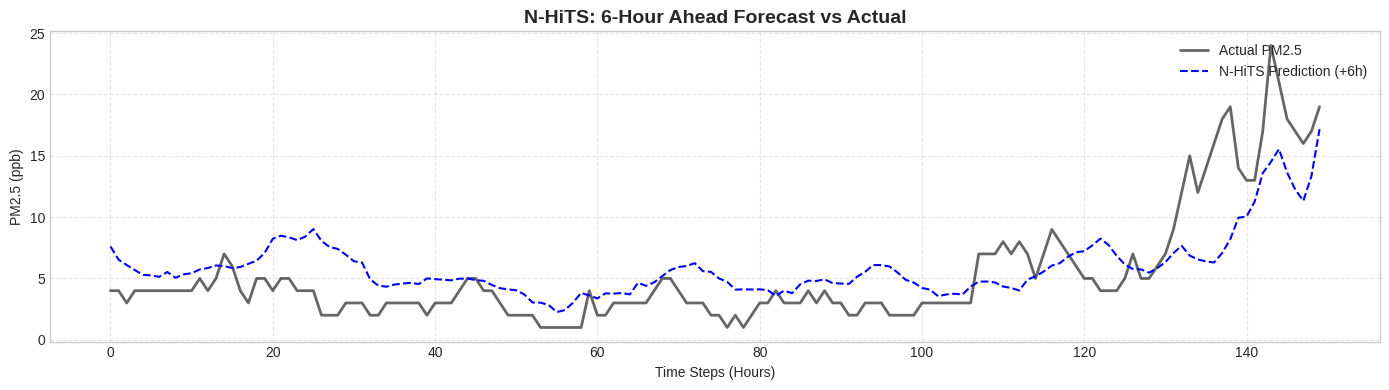

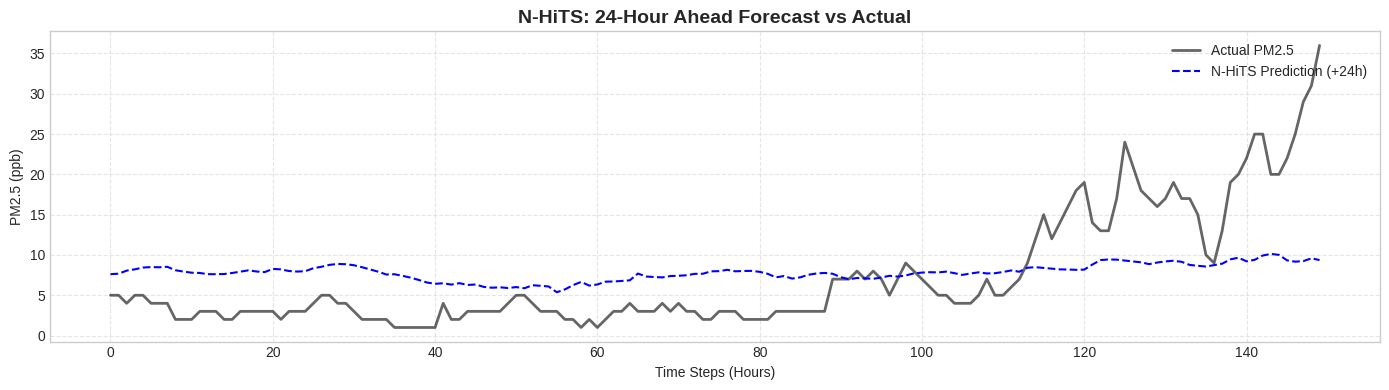

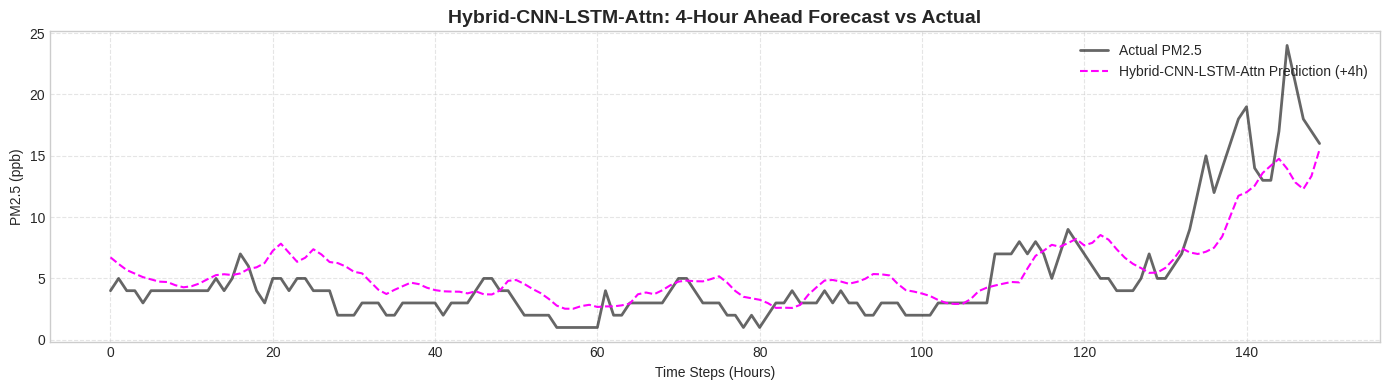

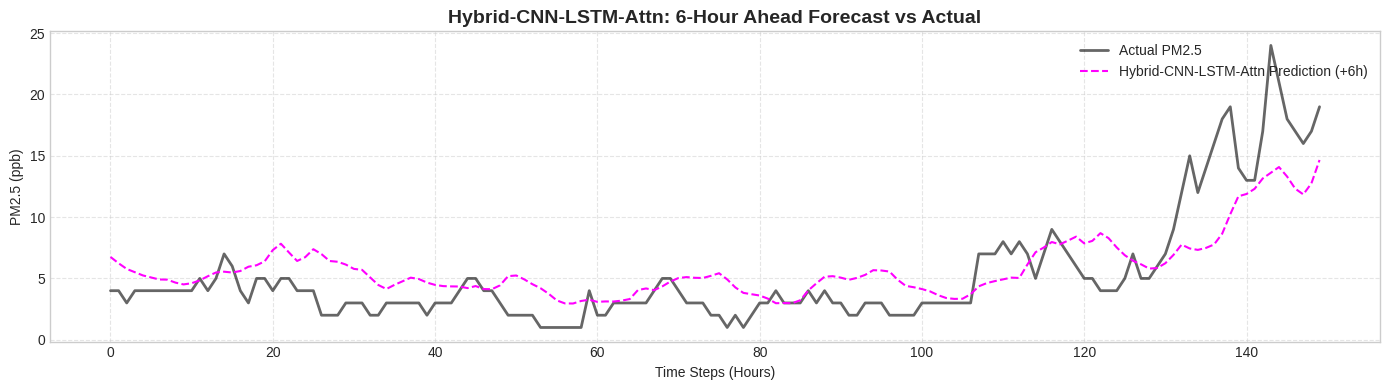

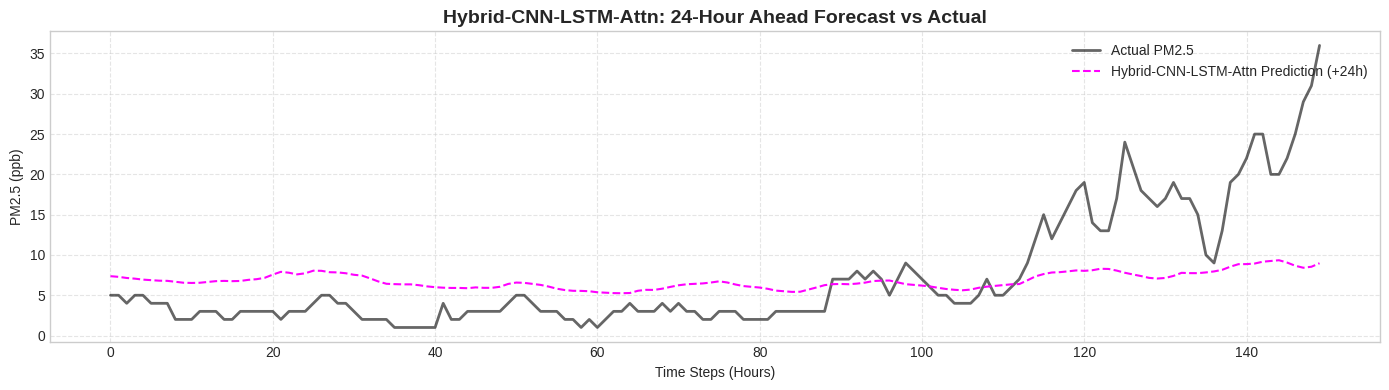

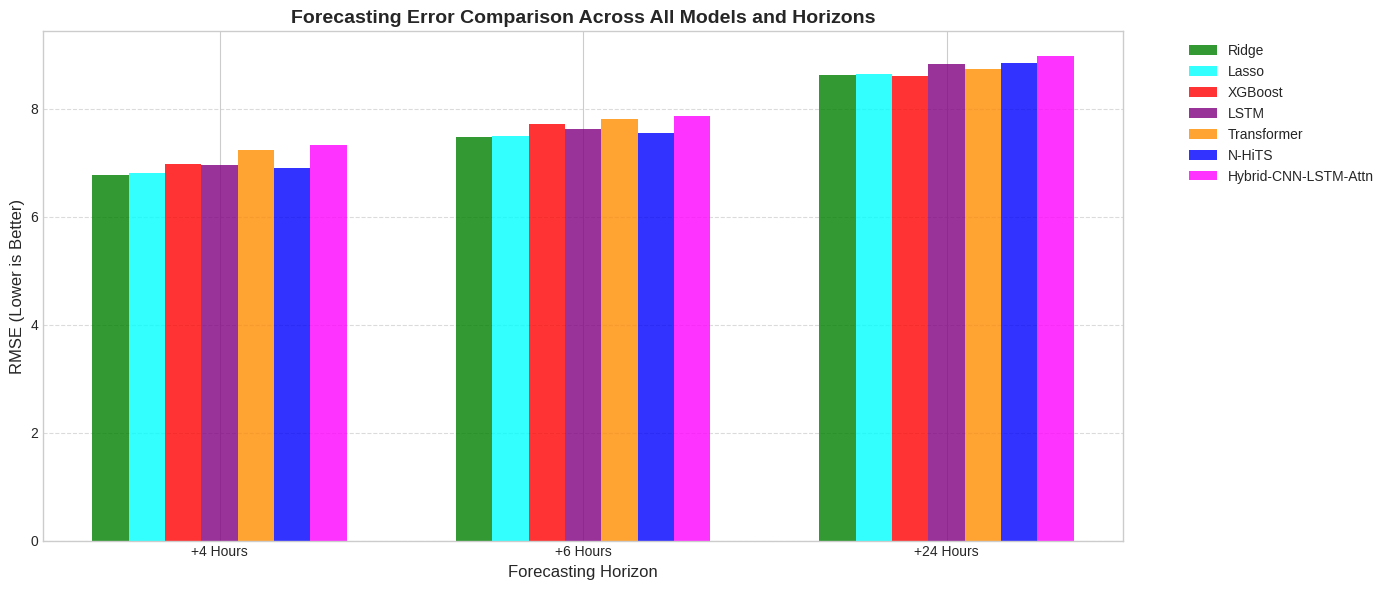

In [10]:
# ==========================================
# 9. Model Predictions vs Actual Visualizations
# ==========================================
PLOT_LEN = 150
colors_map = {'Ridge': 'green', 'Lasso': 'cyan', 'XGBoost': 'red', 'LSTM': 'purple', 'Transformer': 'darkorange', 'N-HiTS': 'blue', 'Hybrid-CNN-LSTM-Attn': 'magenta'}

for model_name in models:
    for h_idx, h in enumerate(HORIZONS):
        plt.figure(figsize=(14, 4))
        plt.plot(y_test_raw[:PLOT_LEN, h_idx], label='Actual PM2.5', color='black', alpha=0.6, linewidth=2)
        plt.plot(predictions_dict[model_name][:PLOT_LEN, h_idx], label=f'{model_name} Prediction (+{h}h)', color=colors_map[model_name], linestyle='--')

        plt.title(f'{model_name}: {h}-Hour Ahead Forecast vs Actual', fontsize=14, fontweight='bold')
        plt.ylabel('PM2.5 (ppb)')
        plt.xlabel('Time Steps (Hours)')
        plt.grid(True, linestyle='--', alpha=0.5)
        plt.legend(loc='upper right')
        plt.tight_layout()
        plt.show()

# Final Bar Chart Comparison
plt.figure(figsize=(14, 6))
bar_width = 0.10
x = np.arange(len(HORIZONS))

for i, model_name in enumerate(models):
    scores = [results_rmse[h][model_name] for h in HORIZONS]
    plt.bar(x + i*bar_width, scores, bar_width, label=model_name, color=colors_map[model_name], alpha=0.8)

plt.xlabel('Forecasting Horizon', fontsize=12)
plt.ylabel('RMSE (Lower is Better)', fontsize=12)
plt.title('Forecasting Error Comparison Across All Models and Horizons', fontsize=14, fontweight='bold')
plt.xticks(x + bar_width * 3, [f"+{h} Hours" for h in HORIZONS])
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()